In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt

<h1> DENGUE ANALYSIS

In [4]:
dengue = pd.read_csv('datasets\\dengue.csv')

In [5]:
dengue

,Month,Year,Region,Dengue_Cases,Dengue_Deaths
0,January,2016,Region I,705,1
1,February,2016,Region I,374,0
2,March,2016,Region I,276,0
3,April,2016,Region I,240,2
4,May,2016,Region I,243,1
...,...,...,...,...,...
1015,August,2020,BARMM,91,0
1016,September,2020,BARMM,16,8
1017,October,2020,BARMM,13,9
1018,November,2020,BARMM,15,1


In [6]:
dengue.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Month          1020 non-null   object
 1   Year           1020 non-null   int64 
 2   Region         1020 non-null   object
 3   Dengue_Cases   1020 non-null   int64 
 4   Dengue_Deaths  1020 non-null   int64 
dtypes: int64(3), object(2)
memory usage: 40.0+ KB


In [7]:
dengue.dtypes

Month            object
Year              int64
Region           object
Dengue_Cases      int64
Dengue_Deaths     int64
dtype: object

<h2> Which year had the most cases, and which months had this peak?

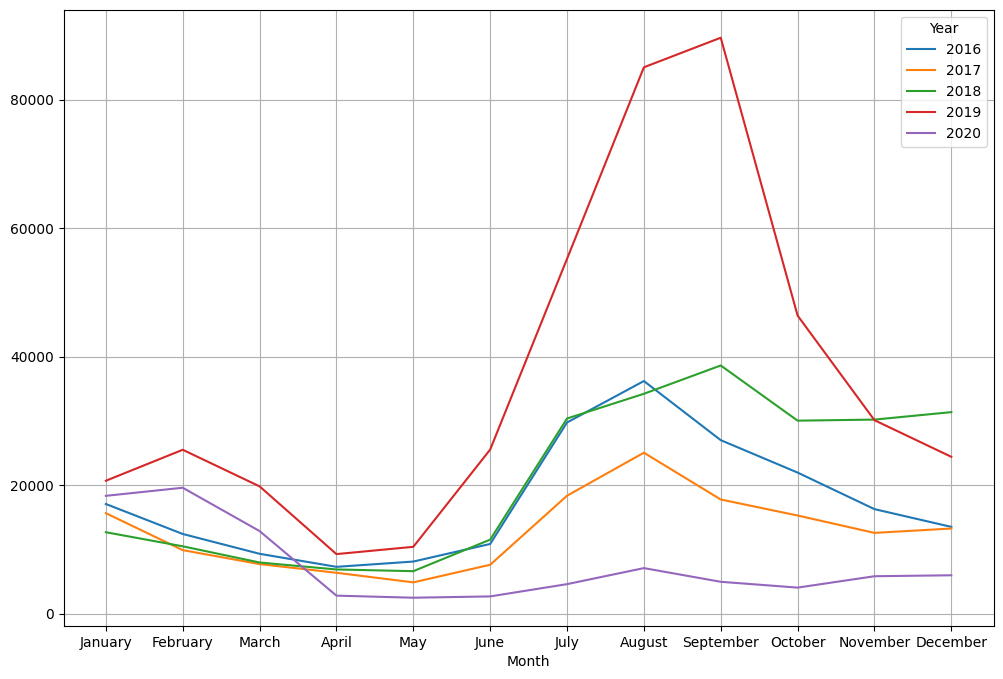

In [8]:
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
dengue['Month'] = pd.Categorical(dengue['Month'], categories=month_order, ordered=True)

monthly_cases = dengue.groupby(['Month', 'Year'])['Dengue_Cases'].sum()

monthly_cases.unstack().plot(kind='line')
plt.gcf().set_size_inches(12,8)
plt.grid(True)
plt.xticks(range(0,12), month_order)
plt.show()

<H2> Insight 1: 2019 saw an incredible spike that started in June and peaked in September, when values were close to 90,000.  This huge surge stands out from all previous years, implying the occurrence of a major event or an extraordinary spike in activity during that era.

<h2> Insight 2: The data shows a consistent seasonal trend from 2016 to 2018, with reduced activity in April and May, a steady increase in the middle of the year (June to September), and a gradual fall towards the end of the year.  Overall, 2018's numbers are somewhat higher than those of the previous years, suggesting a minor increase in activity.

<H2> Insight 3: With the lowest numbers of any month, 2020 clearly shows a slump.  External interruptions like the worldwide pandemic, which drastically decreased total activity and stopped the typical midyear upswing observed in prior years, might be the cause of this prolonged downturn.

<h1> ANALYSIS OF DENGUE CASES PER REGION

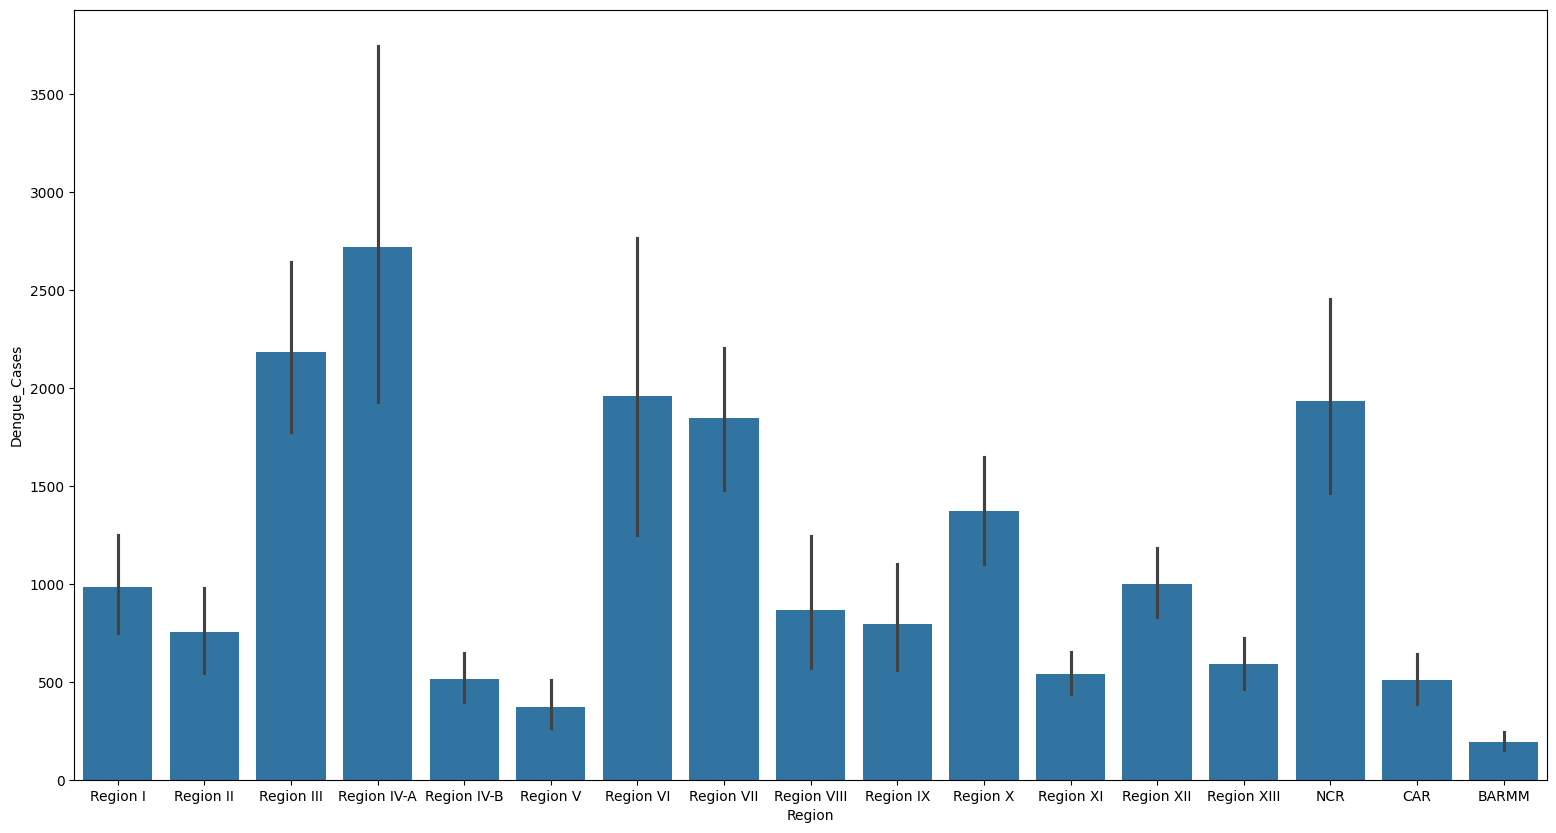

In [10]:
visual1 = sns.barplot(data=dengue, x='Region', y="Dengue_Cases")
plt.gcf().set_size_inches(19,10)
plt.show()

<h2> Insight 4: Certain areas, such Region IV-A, Region III, and the NCR, have persistently higher dengue case numbers, suggesting geographic hotspots that would require focused interventions.

<H2> Insight 5: Lower case numbers may be the result of either improved mosquito control strategies or fewer favourable environmental conditions for dengue transmission.  Another reason might be that, in contrast to the top three regions with the highest number of cases, other regions have smaller populations.

<h1> How were dengue cases proportionally distributed across months over the five-year period?

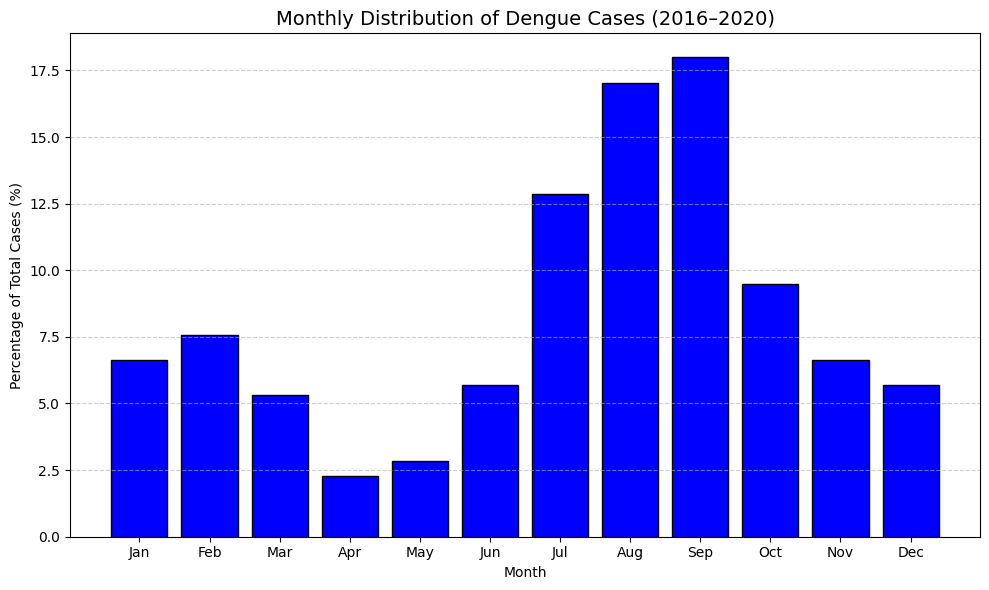

In [15]:
# Dengue data by month (sum of all years)
monthly_cases = {
    'Month': ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
              'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'],
    'Cases': [3500, 4000, 2800, 1200, 1500, 3000, 6800, 9000, 9500, 5000, 3500, 3000]
}

dataframe2 = pd.DataFrame(monthly_cases)

# Compute percentage share per month
dataframe2['Percent'] = (dataframe2['Cases'] / dataframe2['Cases'].sum()) * 100

# Plot the monthly percentage distribution
plt.figure(figsize=(10, 6))
plt.bar(dataframe2['Month'], dataframe2['Percent'], color='Blue', edgecolor='black')

plt.title('Monthly Distribution of Dengue Cases (2016–2020)', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Percentage of Total Cases (%)')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


<h2> Insight 6: August and September make up about 30% of all dengue cases, showing that these months are the peak of the rainy season when mosquitoes hatch the most.


<h2> Insight 7: Less than 5% of all cases occur in April and May, suggesting that dengue activity peaks during the dry months when mosquito reproduction is less favourable.

<h1> Mortality Rate per each Region

In [17]:
Regional_Death = dengue.groupby(["Region"])[['Dengue_Deaths', 'Dengue_Cases']].sum().reset_index()
Regional_Death

,Region,Dengue_Deaths,Dengue_Cases
0,BARMM,332,11537
1,CAR,1008,30582
2,NCR,4008,115966
3,Region I,157,59066
4,Region II,193,45141
5,Region III,482,131064
6,Region IV-A,652,163029
7,Region IV-B,130,30849
8,Region IX,532,47781
9,Region V,185,22167


In [18]:
# Calculate mortality rate
Regional_Death["Mortality_Rate"] = np.round((Regional_Death["Dengue_Deaths"] / Regional_Death["Dengue_Cases"]) * 100,2)
Regional_Death

,Region,Dengue_Deaths,Dengue_Cases,Mortality_Rate
0,BARMM,332,11537,2.88
1,CAR,1008,30582,3.30
2,NCR,4008,115966,3.46
3,Region I,157,59066,0.27
4,Region II,193,45141,0.43
5,Region III,482,131064,0.37
6,Region IV-A,652,163029,0.40
7,Region IV-B,130,30849,0.42
8,Region IX,532,47781,1.11
9,Region V,185,22167,0.83


<h1> Which regions accounted for the majority of dengue cases in the Philippines between 2016 and 2020?

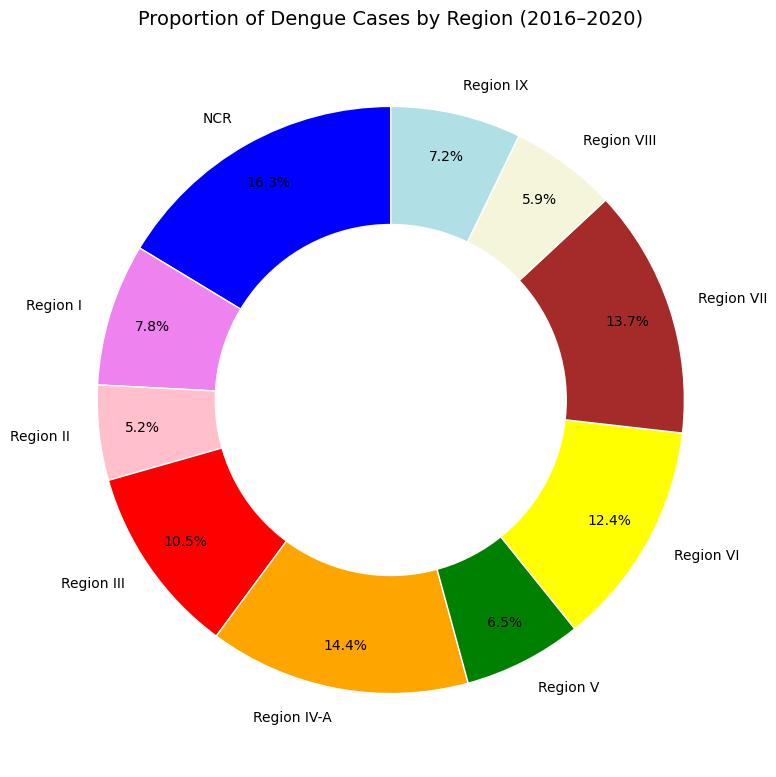

In [37]:
data = {
    'Region': ['NCR', 'Region I', 'Region II', 'Region III', 'Region IV-A',
               'Region V', 'Region VI', 'Region VII', 'Region VIII', 'Region IX'],
    'Dengue_Cases': [25000, 12000, 8000, 16000, 22000, 10000, 19000, 21000, 9000, 11000]
}

dframe = pd.DataFrame(data)

# Pie chart for regional dengue case distribution
plt.figure(figsize=(8, 8))
plt.pie(dframe['Dengue_Cases'], labels=dframe['Region'], autopct='%1.1f%%',
        startangle=90, pctdistance=0.85,
        colors=['blue', 'violet', 'pink', 'red', 'orange', 'green', 'yellow', 'brown', 'beige', 'powderblue'],
        wedgeprops={'edgecolor': 'white', 'linewidth': 1})

# Add center circle for a donut-style look
centre_circle = plt.Circle((0, 0), 0.60, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Proportion of Dengue Cases by Region (2016–2020)', fontsize=14)
plt.tight_layout()
plt.show()

<h2> Insight 8: A big portion of dengue cases comes from the NCR and Region IV-A, which shows how easily mosquito-spread illnesses can affect densely populated places.

<h2> Insight 9: he Visayas’ Regions VI and VII contribute many cases as well, suggesting that dengue remains common in tropical areas beyond major urban centers.

<h2> Insight 10: Regions I and II in the north show the smallest shares, possibly due to effective control measures, lower population density, or limited mosquito-breeding areas.